In [1]:
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

/Users/dquispe/Documents/repositories/ardas_platform/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Simulate 1000 time series samples with 20 time steps each
np.random.seed(42)
X = np.random.randn(1000, 20)  # (samples, time_steps)
y = X[:, -1] * 0.5 + X[:, -2] * -0.3 + np.random.normal(0, 0.1, 1000)  # synthetic target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

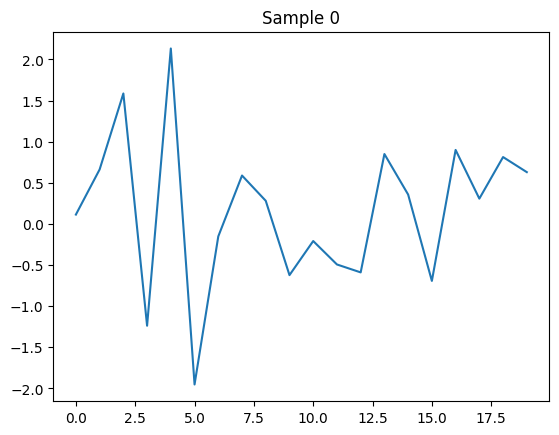

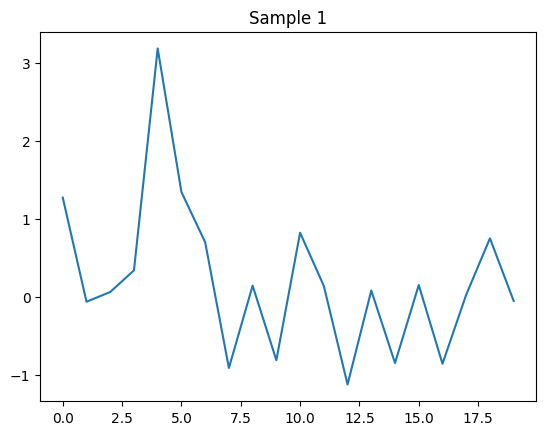

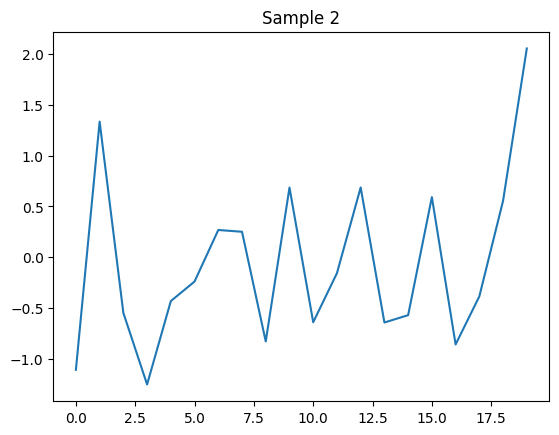

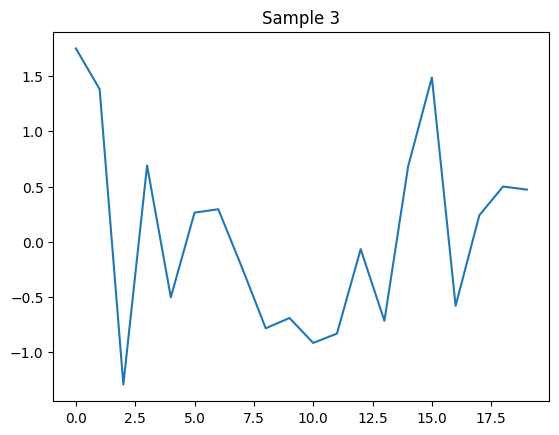

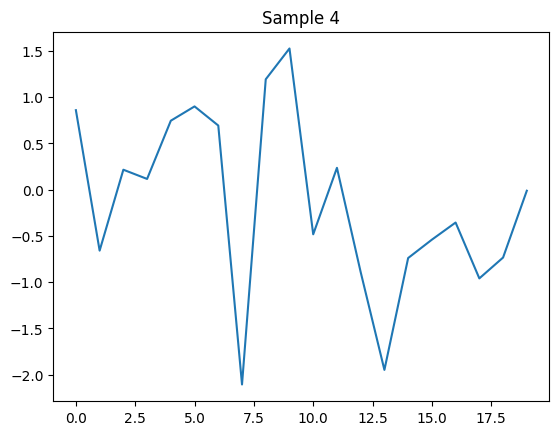

In [3]:
for i in range(5):
    plt.plot(X_train[i])
    plt.title(f"Sample {i}")
    plt.show()

In [4]:
model = RandomForestRegressor()
model.fit(X_train, y_train)

RandomForestRegressor()

In [5]:
# --- Step 5: Compute SHAP Values ---
explainer = shap.Explainer(model.predict, X_train)
shap_values = explainer(X_test)

PermutationExplainer explainer: 201it [00:59,  2.98it/s]                         


In [7]:
# --- Step 6: Select and Explain One Sample ---
time_steps = 20
i = 0  # Index of the test sample to explain
x = np.arange(time_steps)
y_sample = X_test[i]
shap_sample = shap_values[i].values  # SHAP values for each time step


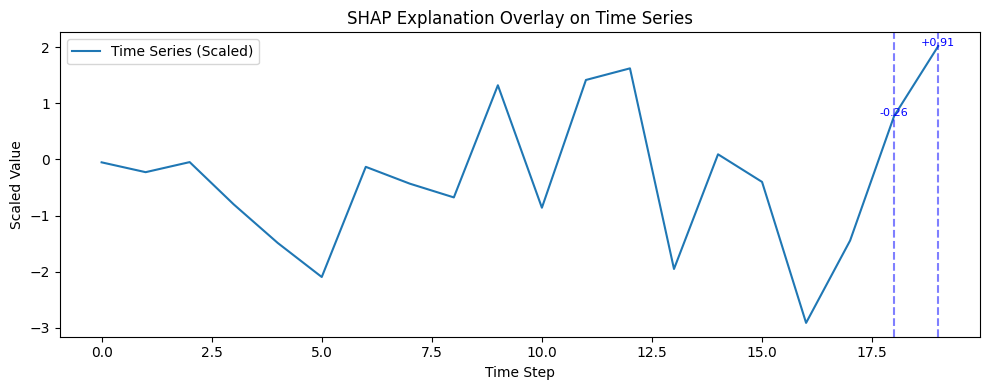

In [8]:
# --- Step 7: Plot 1 - SHAP Overlay on Time Series ---
fig1, ax1 = plt.subplots(figsize=(10, 4))
ax1.plot(x, y_sample, label="Time Series (Scaled)")

threshold = 0.05  # Only annotate SHAP values with noticeable impact
for t, weight in enumerate(shap_sample):
    if abs(weight) > threshold:
        ax1.axvline(t, color='blue', linestyle='--', alpha=0.5)
        ax1.text(t, y_sample[t], f'{weight:+.2f}', color='blue', fontsize=8, ha='center')

ax1.set_title("SHAP Explanation Overlay on Time Series")
ax1.set_xlabel("Time Step")
ax1.set_ylabel("Scaled Value")
ax1.legend()
plt.tight_layout()
plt.show()

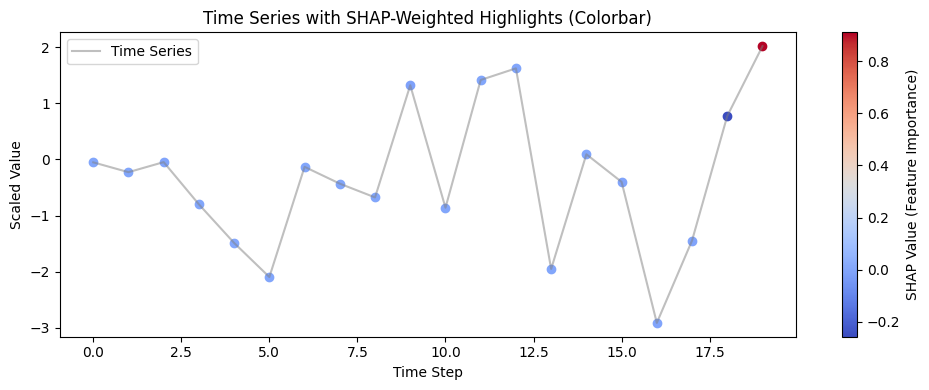

    Time Step  SHAP Value
0           0   -0.000950
1           1    0.001293
2           2   -0.002540
3           3    0.001250
4           4    0.002967
5           5   -0.001653
6           6    0.002342
7           7    0.001504
8           8    0.000418
9           9   -0.011148
10         10   -0.001330
11         11    0.000374
12         12    0.001156
13         13    0.000074
14         14    0.000785
15         15   -0.003328
16         16   -0.002588
17         17   -0.003653
18         18   -0.257661
19         19    0.911104


In [9]:
# --- Step 8: Plot 2 - Color-Mapped SHAP Visualization ---
norm = mcolors.Normalize(vmin=shap_sample.min(), vmax=shap_sample.max())
colors = cm.coolwarm(norm(shap_sample))

fig2, ax2 = plt.subplots(figsize=(10, 4))
for t in range(time_steps):
    ax2.plot(t, y_sample[t], marker='o', color=colors[t])
ax2.plot(x, y_sample, color='gray', alpha=0.5, label="Time Series")

sm = plt.cm.ScalarMappable(cmap='coolwarm', norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax2)
cbar.set_label("SHAP Value (Feature Importance)")

ax2.set_title("Time Series with SHAP-Weighted Highlights (Colorbar)")
ax2.set_xlabel("Time Step")
ax2.set_ylabel("Scaled Value")
ax2.legend()
plt.tight_layout()
plt.show()

# --- Step 9: Print SHAP Values for Inspection ---
shap_df = pd.DataFrame({
    "Time Step": np.arange(time_steps),
    "SHAP Value": shap_sample
})
print(shap_df)

PermutationExplainer explainer: 201it [01:21,  2.17it/s]                         


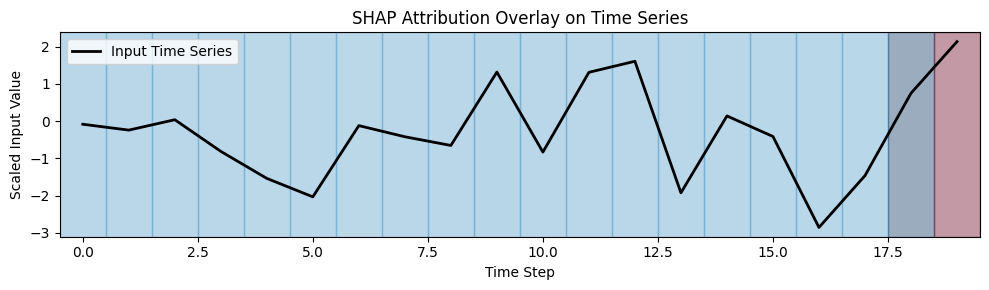

In [ ]:
# Step 5: Attribution-style plot
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(np.arange(len(y_sample)), y_sample, color='black', linewidth=2, label="Input Time Series")

# Add SHAP-colored background
for t in range(len(shap_sample)):
    # Use RdBu_r: blue (negative) to red (positive)
    color = plt.cm.RdBu_r((shap_sample[t] - shap_sample.min()) / (shap_sample.max() - shap_sample.min() + 1e-9))
    ax.axvspan(t - 0.5, t + 0.5, color=color, alpha=0.4)

ax.set_title("SHAP Attribution Overlay on Time Series")
ax.set_xlabel("Time Step")
ax.set_ylabel("Scaled Input Value")
ax.set_xlim(-0.5, len(y_sample) - 0.5)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()